# 📱 Screen Time & Income Level Analysis  
Exploratory Data Analysis (EDA) + ANOVA + Visualization


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, pearsonr

pd.set_option('display.max_columns', None)


In [4]:
url = "https://huggingface.co/datasets/tarekmasryo/digital-lifestyle-benchmark/resolve/main/data/Data.csv"
df = pd.read_csv(url)

df.head()


,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,34,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,102,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,140,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,121,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,60,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


In [5]:
print("Shape:", df.shape)
df.info()
df.describe().T


Shape: (3500, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        3500 non-null   int64  
 1   age                       3500 non-null   int64  
 2   gender                    3500 non-null   object 
 3   region                    3500 non-null   object 
 4   income_level              3500 non-null   object 
 5   education_level           3500 non-null   object 
 6   daily_role                3500 non-null   object 
 7   device_hours_per_day      3500 non-null   float64
 8   phone_unlocks             3500 non-null   int64  
 9   notifications_per_day     3500 non-null   int64  
 10  social_media_mins         3500 non-null   int64  
 11  study_mins                3500 non-null   int64  
 12  physical_activity_days    3500 non-null   float64
 13  sleep_hours               3500 non-null   flo

,count,mean,std,min,25%,50%,75%,max
id,3500.0,1750.500000,1010.507298,1.00,875.750000,1750.500000,2625.250000,3500.000000
age,3500.0,28.078571,9.352385,13.00,21.000000,27.000000,34.000000,50.000000
device_hours_per_day,3500.0,7.317677,3.239838,0.28,4.867500,6.760000,9.152500,17.160000
phone_unlocks,3500.0,147.107429,67.770656,9.00,96.000000,136.000000,187.000000,374.000000
notifications_per_day,3500.0,335.117143,239.678612,22.00,170.000000,268.000000,434.000000,1211.000000
social_media_mins,3500.0,159.362857,132.748048,0.00,68.000000,119.000000,204.000000,631.000000
study_mins,3500.0,108.116571,79.796273,0.00,42.000000,102.000000,163.000000,418.000000
physical_activity_days,3500.0,3.350000,1.877976,0.00,2.000000,3.000000,5.000000,7.000000
sleep_hours,3500.0,7.254481,1.291879,3.00,6.410545,7.291580,8.162298,11.004566
sleep_quality,3500.0,2.708848,1.101105,1.00,1.919438,2.907819,3.276968,5.000000


In [6]:
core_cols = [
    'device_hours_per_day',
    'income_level',
    'stress_level',
    'happiness_score',
    'digital_dependence_score',
    'social_media_mins',
    'sleep_hours'
]

df_clean = df.dropna(subset=core_cols).copy()

df_clean = df_clean[
    (df_clean['device_hours_per_day'] >= 0) &
    (df_clean['device_hours_per_day'] <= 18)
]

df_clean.head()


,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,34,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,102,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,140,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,121,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,60,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


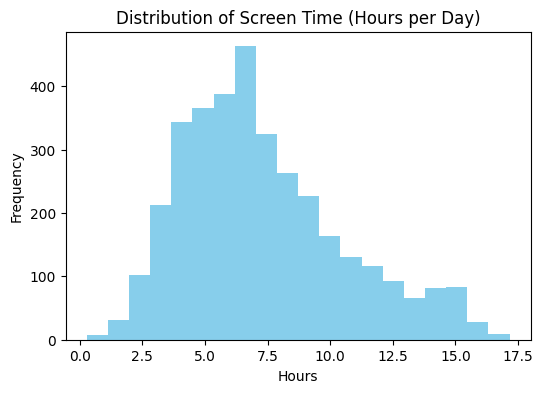

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df_clean['device_hours_per_day'], bins=20, color='skyblue')
plt.title("Distribution of Screen Time (Hours per Day)")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()


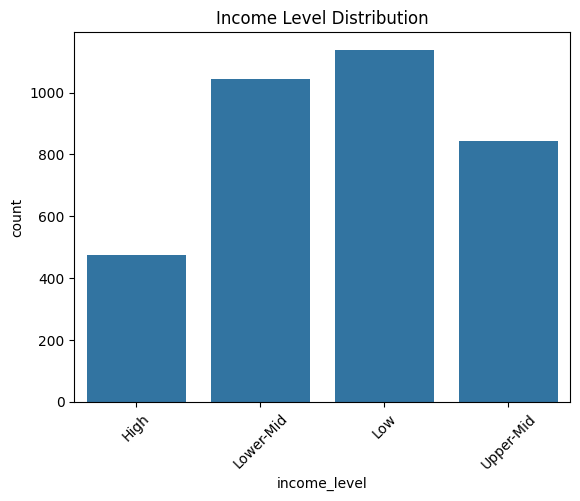

In [8]:
sns.countplot(x="income_level", data=df_clean)
plt.title("Income Level Distribution")
plt.xticks(rotation=45)
plt.show()


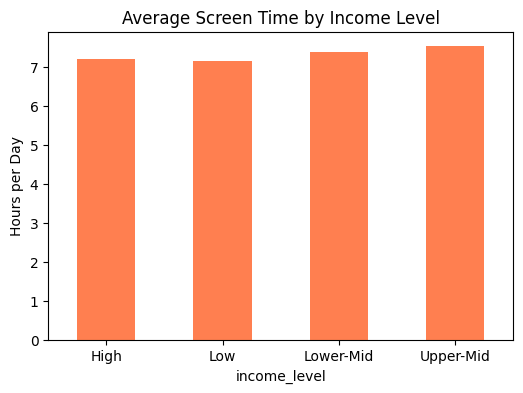

In [9]:
group_means = df_clean.groupby("income_level")["device_hours_per_day"].mean().round(2)
group_means.plot(kind='bar', figsize=(6,4), color='coral')
plt.title("Average Screen Time by Income Level")
plt.ylabel("Hours per Day")
plt.xticks(rotation=0)
plt.show()


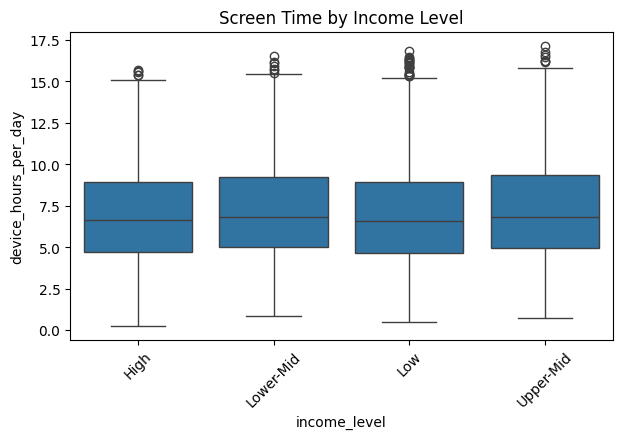

In [10]:
plt.figure(figsize=(7,4))
sns.boxplot(x="income_level", y="device_hours_per_day", data=df_clean)
plt.title("Screen Time by Income Level")
plt.xticks(rotation=45)
plt.show()


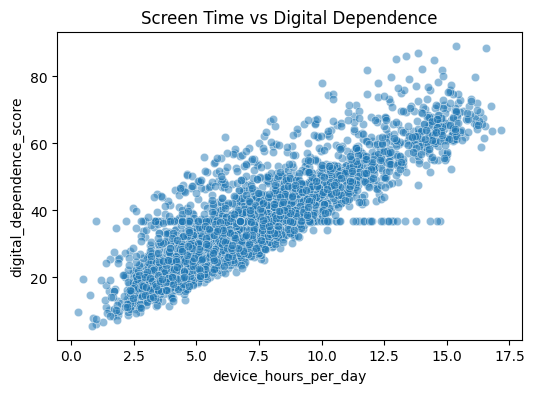

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="device_hours_per_day", y="digital_dependence_score", data=df_clean, alpha=0.5)
plt.title("Screen Time vs Digital Dependence")
plt.show()


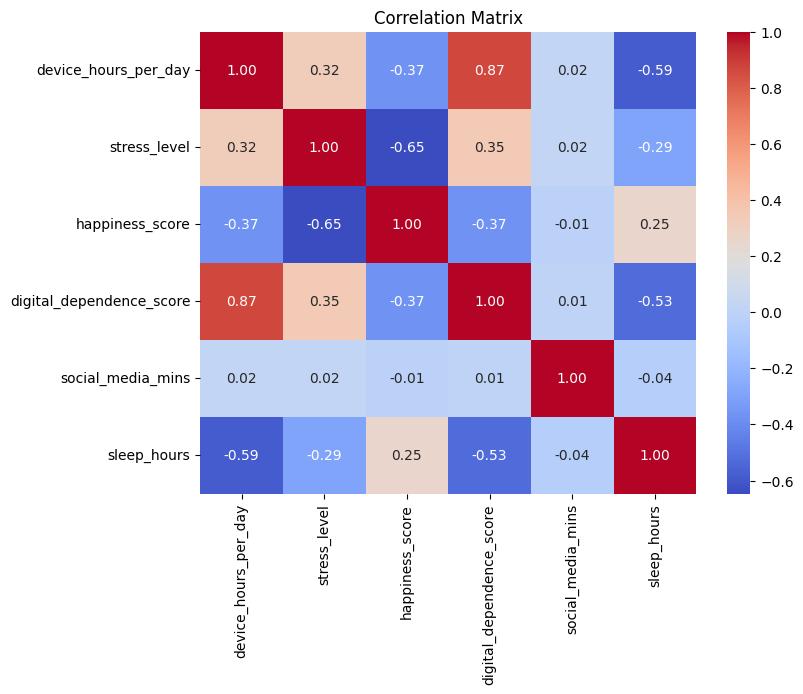

In [12]:
corr_cols = [
    'device_hours_per_day',
    'stress_level',
    'happiness_score',
    'digital_dependence_score',
    'social_media_mins',
    'sleep_hours'
]

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [13]:
low = df_clean[df_clean["income_level"]=="Low"]["device_hours_per_day"]
lowmid = df_clean[df_clean["income_level"]=="Lower-Mid"]["device_hours_per_day"]
upmid = df_clean[df_clean["income_level"]=="Upper-Mid"]["device_hours_per_day"]
high = df_clean[df_clean["income_level"]=="High"]["device_hours_per_day"]

f_stat, p_val = f_oneway(low, lowmid, upmid, high)

print("F-statistic:", f_stat)
print("p-value:", p_val)


F-statistic: 2.560495042371097
p-value: 0.053248520417971866


In [14]:
variables = [
    ('Stress', 'stress_level'),
    ('Happiness', 'happiness_score'),
    ('Digital Dependence', 'digital_dependence_score'),
    ('Social Media', 'social_media_mins'),
    ('Sleep Hours', 'sleep_hours')
]

results = []
for name, col in variables:
    r, p = pearsonr(df_clean['device_hours_per_day'], df_clean[col])
    results.append([name, r, p])

pd.DataFrame(results, columns=['Variable', 'Correlation (r)', 'p-value'])


,Variable,Correlation (r),p-value
0,Stress,0.321165,8.547141e-85
1,Happiness,-0.369274,1.602423e-113
2,Digital Dependence,0.870963,0.000000e+00
3,Social Media,0.023080,1.722094e-01
4,Sleep Hours,-0.587631,0.000000e+00


## Extended Analysis: Screen Time and Well-Being Indicators
In this section, we explore how daily screen time relates to stress, happiness, digital dependence, social media usage, and sleep duration.


In [15]:
from scipy.stats import pearsonr

variables = [
    ('Stress', 'stress_level'),
    ('Happiness', 'happiness_score'),
    ('Digital Dependence', 'digital_dependence_score'),
    ('Social Media Minutes', 'social_media_mins'),
    ('Sleep Hours', 'sleep_hours')
]

results = []
for name, col in variables:
    r, p = pearsonr(df_clean['device_hours_per_day'], df_clean[col])
    results.append([name, r, p])

corr_table = pd.DataFrame(results, columns=['Variable', 'Correlation (r)', 'p-value'])
corr_table


,Variable,Correlation (r),p-value
0,Stress,0.321165,8.547141e-85
1,Happiness,-0.369274,1.602423e-113
2,Digital Dependence,0.870963,0.000000e+00
3,Social Media Minutes,0.023080,1.722094e-01
4,Sleep Hours,-0.587631,0.000000e+00


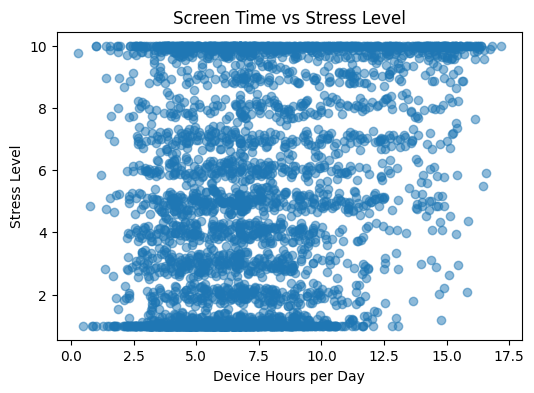

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean['device_hours_per_day'], df_clean['stress_level'], alpha=0.5)
plt.xlabel("Device Hours per Day")
plt.ylabel("Stress Level")
plt.title("Screen Time vs Stress Level")
plt.show()


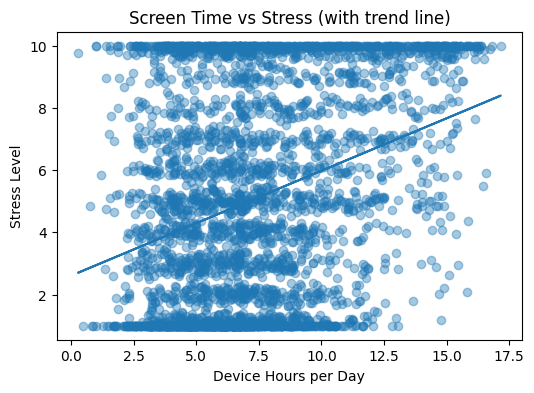

In [17]:
x = df_clean['device_hours_per_day']
y = df_clean['stress_level']

m, b = np.polyfit(x, y, 1)
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.4)
plt.plot(x, m*x + b)
plt.xlabel("Device Hours per Day")
plt.ylabel("Stress Level")
plt.title("Screen Time vs Stress (with trend line)")
plt.show()


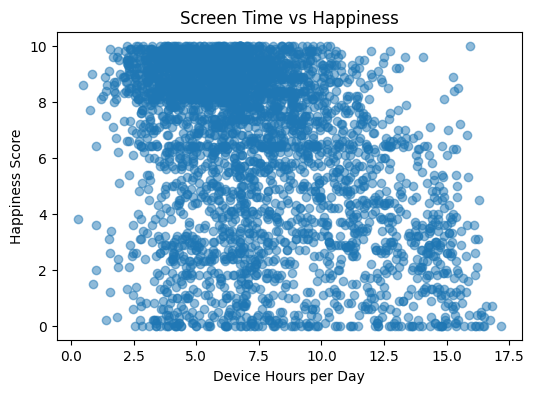

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean['device_hours_per_day'], df_clean['happiness_score'], alpha=0.5)
plt.xlabel("Device Hours per Day")
plt.ylabel("Happiness Score")
plt.title("Screen Time vs Happiness")
plt.show()


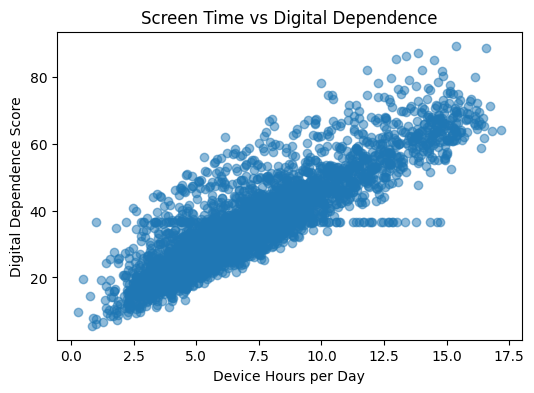

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean['device_hours_per_day'], df_clean['digital_dependence_score'], alpha=0.5)
plt.xlabel("Device Hours per Day")
plt.ylabel("Digital Dependence Score")
plt.title("Screen Time vs Digital Dependence")
plt.show()


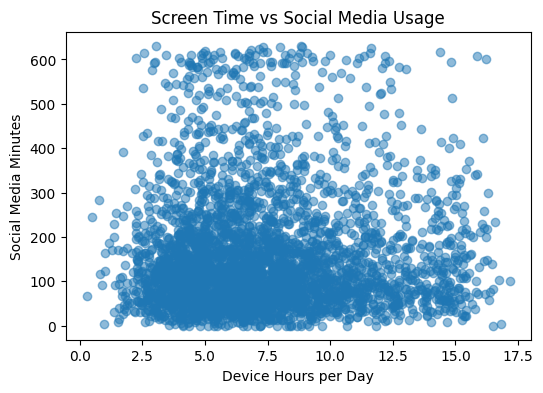

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean['device_hours_per_day'], df_clean['social_media_mins'], alpha=0.5)
plt.xlabel("Device Hours per Day")
plt.ylabel("Social Media Minutes")
plt.title("Screen Time vs Social Media Usage")
plt.show()


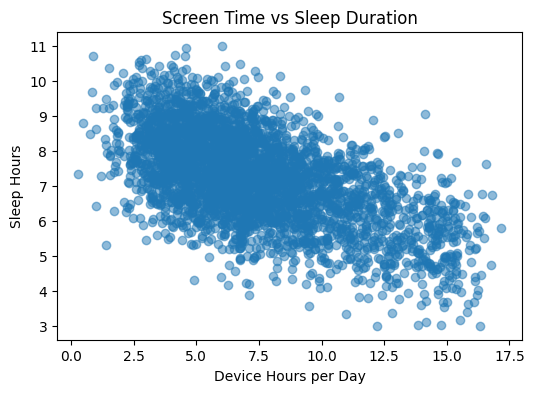

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean['device_hours_per_day'], df_clean['sleep_hours'], alpha=0.5)
plt.xlabel("Device Hours per Day")
plt.ylabel("Sleep Hours")
plt.title("Screen Time vs Sleep Duration")
plt.show()


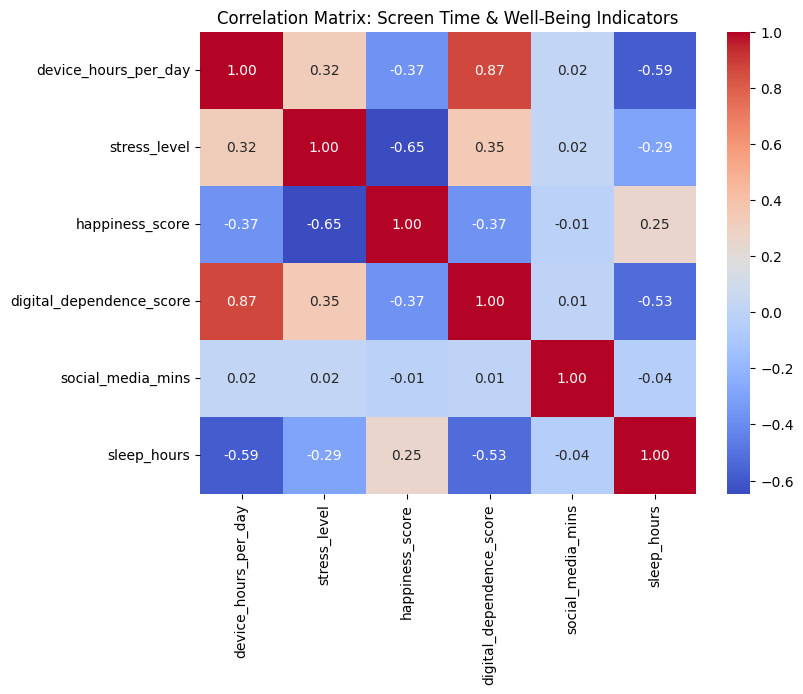

In [22]:
import seaborn as sns

corr_cols = [
    'device_hours_per_day',
    'stress_level',
    'happiness_score',
    'digital_dependence_score',
    'social_media_mins',
    'sleep_hours'
]

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Screen Time & Well-Being Indicators")
plt.show()


In [23]:
low_dep = df_clean[df_clean["income_level"]=="Low"]["digital_dependence_score"]
lowmid_dep = df_clean[df_clean["income_level"]=="Lower-Mid"]["digital_dependence_score"]
upmid_dep = df_clean[df_clean["income_level"]=="Upper-Mid"]["digital_dependence_score"]
high_dep = df_clean[df_clean["income_level"]=="High"]["digital_dependence_score"]

f_stat_dep, p_val_dep = f_oneway(low_dep, lowmid_dep, upmid_dep, high_dep)
print("ANOVA (Income → Digital Dependence)")
print("F-statistic:", f_stat_dep)
print("p-value:", p_val_dep)


ANOVA (Income → Digital Dependence)
F-statistic: 2.292582491318624
p-value: 0.07609232175329424


Now We are starting ML

In [24]:
ml_df = df_clean.copy()

target = "income_level"

features = [
    "device_hours_per_day",
    "social_media_mins",
    "stress_level",
    "happiness_score",
    "digital_dependence_score",
    "sleep_hours",
    "notifications_per_day",
    "phone_unlocks",
    "depression_score",
    "anxiety_score"
]

X = ml_df[features]
y = ml_df[target]


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.3142857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.18      0.02      0.04        98
           1       0.32      0.54      0.40       216
           2       0.32      0.36      0.34       213
           3       0.29      0.14      0.19       173

    accuracy                           0.31       700
   macro avg       0.28      0.27      0.24       700
weighted avg       0.29      0.31      0.28       700



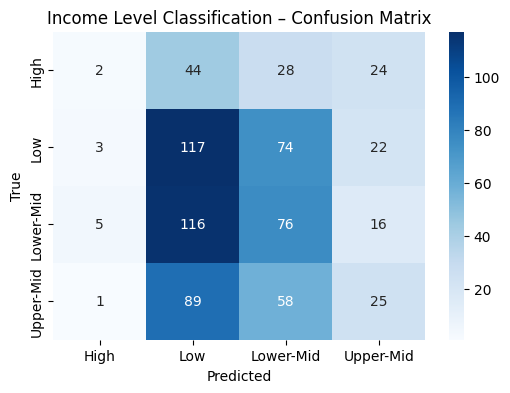

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Income Level Classification – Confusion Matrix")
plt.show()


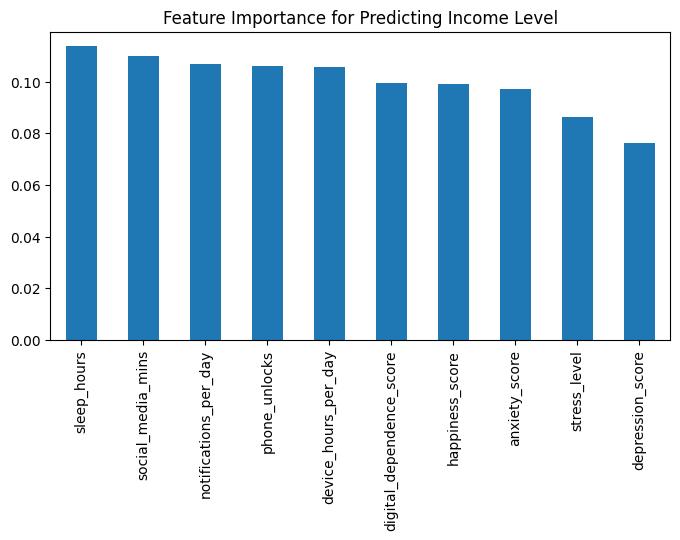

In [29]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(8,4))
plt.title("Feature Importance for Predicting Income Level")
plt.show()
